In [1]:
import model
import data

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader

from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
# device="mps"
## Load Dataset
train_dataset = data.InverseData(mat_file="../Data/NEDC_lite.mat", outputs_npy="../Data/outputs_train.npy", ks_npy="../Data/ks_train.npy")
val_dataset = data.InverseData(mat_file="../Data/NEDC_lite.mat", outputs_npy="../Data/outputs_val.npy", ks_npy="../Data/ks_val.npy")
test_dataset = data.InverseData(mat_file="../Data/NEDC_lite.mat", outputs_npy="../Data/outputs_test.npy", ks_npy="../Data/ks_test.npy")

# train_dataset = train_dataset.to(device)
# val_dataset = val_dataset.to(device)
# test_dataset = test_dataset.to(device)

train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=100, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

In [2]:
best_arch = "./checkpoints/model_lr0.001_nl2_p64_wd0.0_best.pth"
m = model.OperatorNetwork(trunk_input_size=7, branch_input_size=6, num_layers=2, p =64)
m.load_state_dict(torch.load(best_arch, map_location=torch.device('cpu'))["model_state_dict"])

<All keys matched successfully>

In [3]:
with torch.no_grad():
    for batch in tqdm(test_loader):
        A, seq, out = batch
        # seq, A, out = seq.to(device), A.to(device), out.to(device)
        predictions = m(seq=seq, A=A)
        

100%|██████████| 1/1 [00:04<00:00,  4.22s/it]


Text(0.5, 1.0, 'Predicted Output NOx Signal vs True Output NOx signal')

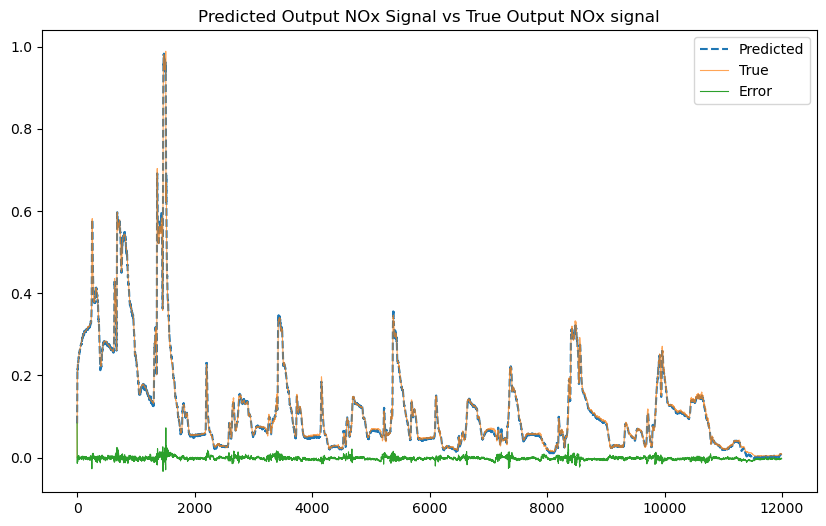

In [11]:
import matplotlib.pyplot as plt

index = 10

plt.figure(figsize=(10, 6))
plt.plot(predictions[index].cpu().numpy(), label="Predicted", linestyle="dashed", alpha = 1)
plt.plot(out[index].cpu().numpy(), label="True", alpha=0.7, linewidth = 0.8)
plt.plot(predictions[index].cpu().numpy() - out[index].cpu().numpy(), label="Error", linewidth=0.8)
plt.legend()
plt.title("Predicted Output NOx Signal vs True Output NOx signal")

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np

def optimize_inverse_parameters(trunk_input, target_output, model, lr=0.05, inv_epochs=1000, patience=50, means=None, stds=None, device='cpu'):
    """
    Runs inverse modeling on a frozen DeepONet to find the optimal Branch inputs (A values)
    across the entire unmasked sequence.
    """
    
    # 1. Freeze model weights
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

    # 2. Move data to device
    trunk_input = trunk_input.unsqueeze(0).to(device)
    target_output = target_output.unsqueeze(0).to(device)

    # 3. Pre-compute Trunk basis
    print("Pre-computing Trunk basis functions...")
    with torch.no_grad():
        basis = model.trunk(trunk_input)

    # 4. Initialize A_guess
    A_guess = nn.Parameter(torch.randn(1, 6, device=device))

    optimizer_inv = torch.optim.Adam([A_guess], lr=lr)
    criterion = nn.MSELoss()

    best_inv_loss = float('inf')
    epochs_no_improve = 0
    best_A = None

    pbar = tqdm(range(inv_epochs), desc="Optimizing A values")

    # 5. Optimization Loop
    for step in pbar:
        optimizer_inv.zero_grad()

        coeff = model.branch(A_guess)
        
        # Recombine basis and coeff
        pred = torch.einsum('btp,bp->bt', basis, coeff).unsqueeze(-1) 

        # Calculate loss directly on the full sequences
        loss = criterion(pred, target_output)
        
        loss.backward()
        optimizer_inv.step()

        current_loss = loss.item()
        pbar.set_postfix({'Loss': f"{current_loss:.6f}"})

        if current_loss < best_inv_loss:
            best_inv_loss = current_loss
            best_A = A_guess.detach().clone()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            pbar.write(f"Early stopping triggered at step {step}.")
            break

    print(f"\nOptimization Complete! Best Loss: {best_inv_loss:.6f}")
    
    if best_A is None:
        return None, None

    # 6. Un-normalize
    final_A_normalized = best_A.cpu().flatten()
    
    if means is not None and stds is not None:
        final_A = (final_A_normalized * stds) + means
        return final_A
    else:
        print("Means and standard deviations not provided; skipping physical un-normalization.")
        return final_A_normalized

In [ ]:
A_guess = optimize_inverse_parameters(trunk_input=seq[0], target_output=out[0], model=m, lr=0.05, inv_epochs=1000, patience=300, means=None, stds=None, device="cpu")

In [ ]:
A[0], A_guess

In [ ]:
recon_with_A_guess = m(seq=seq[0].unsqueeze(0), A=A_guess.unsqueeze(0))
recon_with_A_act = m(seq=seq[0].unsqueeze(0), A=A[0].unsqueeze(0))


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(recon_with_A_guess.cpu().numpy().flatten(), label="Reconstruction with A_guess")
plt.plot(recon_with_A_act.cpu().numpy().flatten(), label="Reconstruction with A_actual")
plt.plot(recon_with_A_act.cpu().numpy().flatten() - recon_with_A_guess.cpu().numpy().flatten(), label="Difference")
# plt.plot(out[0].cpu().numpy().flatten(), label="True Output", linestyle='dashed')

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

trunk_input = seq[0].unsqueeze(0)

# ==========================================
# 1. SETUP & PRIOR BOUNDS
# ==========================================
param_names = ["A_ads", "A_des", "A_std", "A_fst", "A_slw", "A_oxi"]

A_mean = np.array([5.0, 5e04, 4e09, 2e09, 6e11, 7e03], dtype=float)
A_std = np.array([2.0, 2e04, 8e08, 5e08, 2e11, 2e03], dtype=float)

# Prior bounds: mean ± 2 std
A_lower = A_mean - 2.0 * A_std
A_upper = A_mean + 2.0 * A_std

# For synthetic testing, we need a known "true" A vector
A_true = np.array([4.5, 4.8e04, 3.5e09, 2.2e09, 5.5e11, 6.8e03], dtype=float)

def z_to_A(z):
    z = np.asarray(z, dtype=float)
    return A_lower + z * (A_upper - A_lower)

def A_to_z(A):
    A = np.asarray(A, dtype=float)
    return (A - A_lower) / (A_upper - A_lower)

z_true = A_to_z(A_true)

# ==========================================
# 2. DEEPONET SURROGATE PREPARATION
# ==========================================
# Assuming 'm', 'trunk_input', and 'device' are already loaded in your environment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

m.eval()
for param in m.parameters():
    param.requires_grad = False

trunk_input = trunk_input.to(device)

print("Pre-computing Trunk basis functions...")
with torch.no_grad():
    basis = m.trunk(trunk_input) # Shape: [1, seq_len, p]

# Generate synthetic observation using the true parameters
print("Generating synthetic observation...")
A_true_tensor = torch.tensor(A_true, dtype=torch.float32, device=device).unsqueeze(0)
with torch.no_grad():
    coeff_true = m.branch(A_true_tensor)
    y_obs_tensor = torch.einsum('btp,bp->bt', basis, coeff_true).unsqueeze(-1)
    
y_obs = y_obs_tensor.cpu().numpy()

# Add noise to the observation
eta_noise = 0.2
sigma_y = eta_noise * np.sqrt(np.mean(y_obs**2))
y_obs_noisy = y_obs + np.random.normal(0, sigma_y, size=y_obs.shape)

print(f"Noise setting (sigma_y): {sigma_y:.6e}")

# ==========================================
# 3. MCMC PROBABILITY FUNCTIONS
# ==========================================
def log_prior_z(z):
    z = np.asarray(z, dtype=float)
    if np.all((z >= 0.0) & (z <= 1.0)):
        return 0.0
    return -np.inf

def log_likelihood_z(z):
    A = z_to_A(z)
    
    # 1. Convert to tensor
    A_tensor = torch.tensor(A, dtype=torch.float32, device=device).unsqueeze(0)
    
    # 2. Evaluate DeepONet Branch
    with torch.no_grad():
        coeff = m.branch(A_tensor)
        y_pred_tensor = torch.einsum('btp,bp->bt', basis, coeff).unsqueeze(-1)
        
    # 3. Calculate residual
    y_pred = y_pred_tensor.cpu().numpy()
    residual = y_obs_noisy - y_pred
    
    return -0.5 * np.sum((residual / sigma_y) ** 2)

def log_posterior_z(z):
    lp = log_prior_z(z)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_z(z)

# ==========================================
# 4. METROPOLIS-HASTINGS SAMPLER
# ==========================================
def run_mcmc(logpost_fn, z0, n_steps=20000, proposal_std=0.03, seed=0):
    rng = np.random.default_rng(seed)
    z_current = np.asarray(z0, dtype=float).copy()
    logp_current = logpost_fn(z_current)

    samples = np.zeros((n_steps, len(z_current)))
    logps = np.zeros(n_steps)
    accepted = np.zeros(n_steps, dtype=bool)

    for i in range(n_steps):
        # Random walk proposal
        z_proposal = z_current + proposal_std * rng.normal(size=len(z_current))
        logp_proposal = logpost_fn(z_proposal)

        # Acceptance logic
        log_alpha = logp_proposal - logp_current
        if np.log(rng.random()) < log_alpha:
            z_current = z_proposal
            logp_current = logp_proposal
            accepted[i] = True

        samples[i] = z_current
        logps[i] = logp_current
        
        if i % 5000 == 0:
            print(f"Step {i}/{n_steps} | Accept Rate: {accepted[:i+1].mean():.3f}")

    accept_rate = accepted.mean()
    return samples, logps, accept_rate

# ==========================================
# 5. EXECUTION & PLOTTING
# ==========================================
# Start near the center of the prior box (0.5 for all normalized parameters)
z0 = np.full(6, 0.5)

print("\nStarting MCMC...")
samples_z, logps, accept_rate = run_mcmc(
    logpost_fn=log_posterior_z,
    z0=z0,  # Changed from z_true so it actually has to search for the solution
    n_steps=20000,
    proposal_std=0.015,
    seed=42,
)

samples_A = z_to_A(samples_z)

print("\nMCMC finished")
print(f"Acceptance rate: {accept_rate:.3f}")

# --- Plotting Trace ---
burn_in = 5000
fig, axes = plt.subplots(6, 1, figsize=(9, 8), sharex=True)

for j, ax in enumerate(axes):
    ax.plot(samples_z[:, j], linewidth=0.8, alpha=0.7)
    ax.axhline(z_true[j], color="k", linestyle="--", linewidth=1.5, label="true")
    ax.axvline(burn_in, color="red", linestyle=":", linewidth=1.5, label="burn-in")
    ax.set_ylabel(param_names[j])
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("MCMC step")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.savefig("mcmc_trace.png", dpi=300)
plt.close()

# --- Plotting Histograms ---
samples_z_post = samples_z[burn_in:]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

for j, ax in enumerate(axes):
    ax.hist(samples_z_post[:, j], bins=40, density=True, alpha=0.75, color='steelblue')
    ax.axvline(z_true[j], color="k", linestyle="--", linewidth=2, label="true")
    ax.axvline(samples_z_post[:, j].mean(), color="r", linestyle="-", linewidth=2, label="mean")
    ax.set_title(param_names[j])
    ax.set_xlabel("Normalized Value (z)")
    ax.set_ylabel("Density")
    ax.set_xlim(0.0, 1.0)
    ax.grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.savefig("mcmc_histograms.png", dpi=300)
plt.close()

print("Plots saved as 'mcmc_trace.png' and 'mcmc_histograms.png'.")

In [12]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

# ==========================================
# 1. FAST INVERSE SOLVER FUNCTION
# ==========================================
def solve_inverse_point_estimate(trunk_input, target_output, model, device, lr=0.05, steps=500):
    """
    Rapidly optimizes A_guess for a single sample.
    Assumes trunk_input and target_output already have a batch dimension of 1.
    """
    # Pre-compute the basis once for speed
    with torch.no_grad():
        basis = model.trunk(trunk_input)
        
    # Initialize A_guess at 0 (the standardized mean)
    A_guess = nn.Parameter(torch.zeros(1, 6, device=device))
    
    optimizer = torch.optim.Adam([A_guess], lr=lr)
    criterion = nn.MSELoss()
    
    for _ in range(steps):
        optimizer.zero_grad()
        
        coeff = model.branch(A_guess)
        
        # Add model.bias here if your OperatorNetwork uses it
        pred = torch.einsum('btp,bp->bt', basis, coeff).unsqueeze(-1)
        
        loss = criterion(pred, target_output)
        loss.backward()
        optimizer.step()
        
    return A_guess.detach()

# ==========================================
# 2. EVALUATION LOOP OVER TEST LOADER
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure model is strictly in eval mode and frozen
m.eval()
for param in m.parameters():
    param.requires_grad = False

all_A_true = []
all_A_pred = []

print(f"Starting inverse evaluation over {len(test_loader.dataset)} test samples...")

# Iterate over the test_loader
for batch in tqdm(test_loader, desc="Evaluating Test Set"):
    branch_inputs, trunk_inputs, targets = [b.to(device) for b in batch]
    
    batch_size = targets.size(0)
    
    # Process each item in the batch individually
    for i in range(batch_size):
        # Slice with [i:i+1] to preserve the batch dimension of 1
        # Equivalent to seq[i].unsqueeze(0)
        A_true_i = branch_inputs[i:i+1] 
        seq_i = trunk_inputs[i:i+1]     
        target_i = targets[i:i+1]       
        
        # Run the inverse solver
        A_pred_i = solve_inverse_point_estimate(
            trunk_input=seq_i, 
            target_output=target_i, 
            model=m, 
            device=device,
            lr=0.05,
            steps=500 # Adjust steps based on how fast it converges
        )
        
        # Store results for RMSE calculation
        all_A_true.append(A_true_i.cpu().numpy().flatten())
        all_A_pred.append(A_pred_i.cpu().numpy().flatten())

# ==========================================
# 3. RMSE CALCULATION & REPORTING
# ==========================================
# Convert lists to numpy arrays for vectorized math. Shape: [num_samples, 6]
all_A_true = np.array(all_A_true)
all_A_pred = np.array(all_A_pred)

# Calculate Squared Errors
squared_errors = (all_A_pred - all_A_true) ** 2

# Calculate RMSE per parameter (column-wise)
rmse_per_param = np.sqrt(np.mean(squared_errors, axis=0))

# Calculate Total Overall RMSE
overall_rmse = np.sqrt(np.mean(squared_errors))

# Output the results
param_names = ["A_ads", "A_des", "A_std", "A_fst", "A_slw", "A_oxi"]

print("\n" + "="*40)
print("INVERSE RECOVERY RMSE RESULTS (NORMALIZED)")
print("="*40)
print(f"Overall Total RMSE: {overall_rmse:.6f}\n")

for name, rmse_val in zip(param_names, rmse_per_param):
    print(f"{name:6s} RMSE: {rmse_val:.6f}")

# Optional: To calculate physical RMSE, you would apply your un-normalization 
# math to all_A_true and all_A_pred before doing the squared_errors calculation.

Starting inverse evaluation over 100 test samples...


Evaluating Test Set: 100%|██████████| 1/1 [00:33<00:00, 33.42s/it]


INVERSE RECOVERY RMSE RESULTS (NORMALIZED)
Overall Total RMSE: 1.000276

A_ads  RMSE: 1.335548
A_des  RMSE: 1.668478
A_std  RMSE: 0.204356
A_fst  RMSE: 0.258179
A_slw  RMSE: 0.331540
A_oxi  RMSE: 1.103392
